In [1]:
%cd ../ # hack for correct imports
import matplotlib.pyplot as plt
import numpy as np
from src.data_loader import CoffeeDataset

dataset = CoffeeDataset("train")

C:\Users\atopo\PycharmProjects\coffee-grind-analysis


In [105]:
from scipy.ndimage import uniform_filter
from tqdm import tqdm

def get_mask(img):
    reshaped = img.reshape(-1, 3)
    color = np.array([160, 82, 45]).reshape(3, 1) # setup for a brown color
    color_norm = (color/np.linalg.norm(color, axis=0, keepdims=True))
    closeness = (reshaped/np.linalg.norm(reshaped, axis=1, keepdims=True)) @ color_norm
    closeness_blurred = (closeness.reshape(1080, 1080) >  closeness.mean()).astype("float")
    closeness_blurred = uniform_filter(closeness_blurred, 62)
    return closeness_blurred[..., None] > 0.95

def find_first_nonzero(img, axis):
    first_pixel_columns = (img > 0).all(axis=-1).argmax(axis=axis)
    return first_pixel_columns[first_pixel_columns > 0].min()

def extract_coffe(img, cropping=False):
    mask = get_mask(img)
    masked = img * mask
    if not cropping:
        return masked
    first_pixel_columns = find_first_nonzero(masked, 0)
    first_pixel_rows = find_first_nonzero(masked, 1)
    last_pixel_columns = masked.shape[0] - find_first_nonzero(masked[::-1, ...], 0)
    last_pixel_rows = masked.shape[1] - find_first_nonzero(masked[::-1, ...], 1)
    return masked[first_pixel_columns:last_pixel_columns, first_pixel_rows:last_pixel_rows]
    
shapes = []
for i in tqdm(dataset):
    img = np.asarray(i[0])
    shapes.append(extract_coffe(img, True).shape)

shapes = np.asarray(shapes)
print(shapes.max(axis=0))

100%|██████████| 520/520 [01:37<00:00,  5.36it/s]

[528 892   3]


Max size of the cropped image is 528x892 px

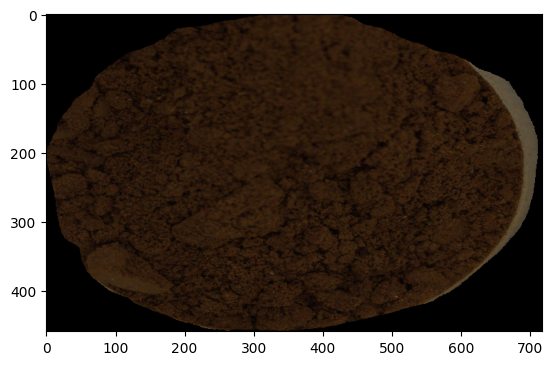

In [106]:
i = np.asarray(dataset[60][0])
plt.imshow(extract_coffe(i, True))